In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
df = pd.read_csv('sales_data.csv', encoding='latin1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort by date
df = df.sort_values('Order Date')

# Remove empty rows
df = df.dropna()

# Create new time columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

print("✅ Data cleaned!")
print("Total records:", len(df))

✅ Data cleaned!
Total records: 9994


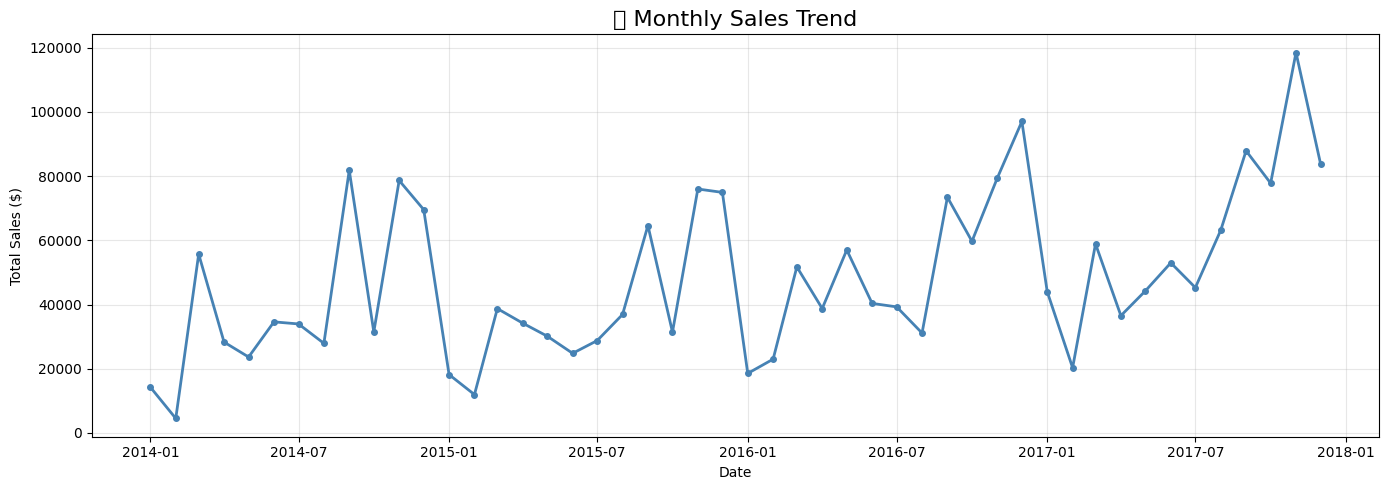

✅ Chart saved!


In [4]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(
    monthly_sales[['Year', 'Month']].assign(Day=1)
)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'],
         color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('📈 Monthly Sales Trend', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()

print("✅ Chart saved!")

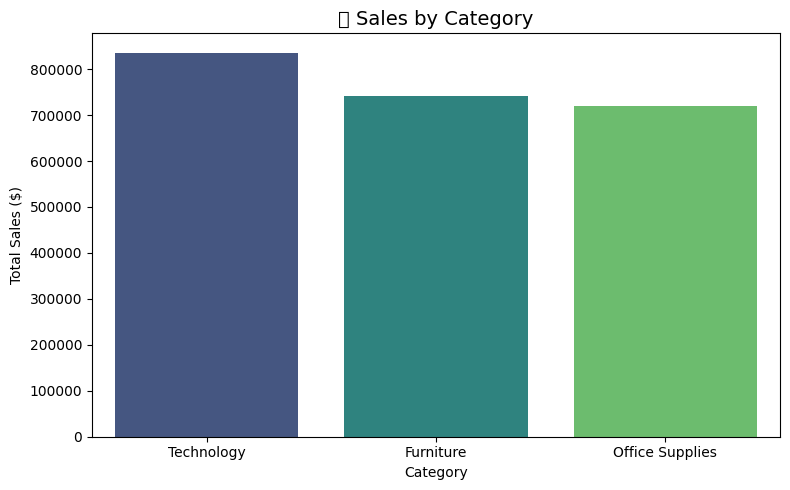

✅ Category chart saved!


In [5]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('💼 Sales by Category', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.xlabel('Category')
plt.tight_layout()
plt.savefig('sales_by_category.png', dpi=150)
plt.show()

print("✅ Category chart saved!")

In [6]:
# Input features
X = df[['Year', 'Month', 'Quarter', 'DayOfWeek']]

# What we want to predict
y = df['Sales']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

# Create and train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Check accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\n✅ Model trained!")
print(f"📊 Mean Absolute Error : ${mae:.2f}")
print(f"📊 R² Score            : {r2:.2f}")
print(f"\n💡 R² closer to 1.0 = better accuracy")

Training rows: 7995
Testing rows:  1999

✅ Model trained!
📊 Mean Absolute Error : $269.44
📊 R² Score            : -0.02

💡 R² closer to 1.0 = better accuracy


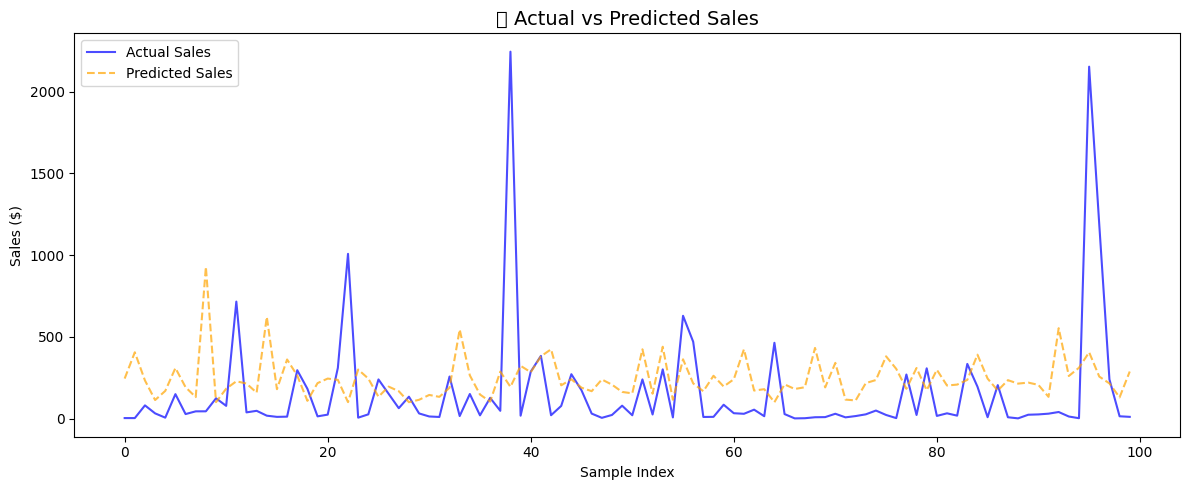

✅ Comparison chart saved!


In [7]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label='Actual Sales',
         color='blue', alpha=0.7)
plt.plot(predictions[:100], label='Predicted Sales',
         color='orange', alpha=0.7, linestyle='--')
plt.title('🎯 Actual vs Predicted Sales', fontsize=14)
plt.xlabel('Sample Index')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

print("✅ Comparison chart saved!")

📅 Sales Forecast — Next 6 Months:
-----------------------------------
  January     : $361.96
  February    : $115.63
  March       : $618.25
  April       : $170.36
  May         : $116.60
  June        : $273.74


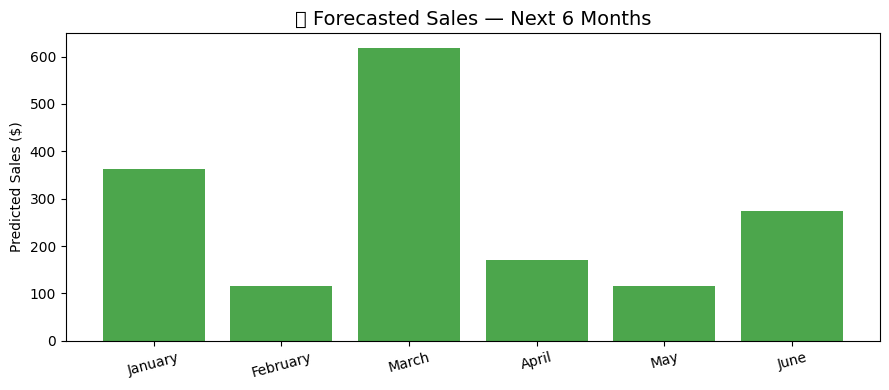


✅ Forecast chart saved!


In [8]:
future_months = pd.DataFrame({
    'Year':      [2025, 2025, 2025, 2025, 2025, 2025],
    'Month':     [1, 2, 3, 4, 5, 6],
    'Quarter':   [1, 1, 1, 2, 2, 2],
    'DayOfWeek': [3, 3, 3, 3, 3, 3]
})

future_preds = model.predict(future_months)

months = ['January', 'February', 'March', 'April', 'May', 'June']
print("📅 Sales Forecast — Next 6 Months:")
print("-" * 35)
for m, p in zip(months, future_preds):
    print(f"  {m:<12}: ${p:,.2f}")

plt.figure(figsize=(9, 4))
plt.bar(months, future_preds, color='green', alpha=0.7)
plt.title('🔮 Forecasted Sales — Next 6 Months', fontsize=14)
plt.ylabel('Predicted Sales ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150)
plt.show()

print("\n✅ Forecast chart saved!")

In [9]:
best_month  = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
worst_month = monthly_sales.loc[monthly_sales['Sales'].idxmin()]
top_cat     = category_sales.index[0]
low_cat     = category_sales.index[-1]

print("=" * 50)
print("       📋 BUSINESS INSIGHTS REPORT")
print("=" * 50)

print(f"\n✅ Best Sales Period:")
print(f"   Month {int(best_month['Month'])}/{int(best_month['Year'])}")
print(f"   Revenue: ${best_month['Sales']:,.2f}")

print(f"\n⚠️  Weakest Sales Period:")
print(f"   Month {int(worst_month['Month'])}/{int(worst_month['Year'])}")
print(f"   Revenue: ${worst_month['Sales']:,.2f}")

print(f"\n🏆 Top Category    : {top_cat}")
print(f"📉 Lowest Category : {low_cat}")

print(f"\n🤖 Model R² Score  : {r2:.2%}")
print(f"📉 Avg Prediction Error : ${mae:,.2f}")

print(f"\n💡 Recommendations:")
print(f"   1. Stock more in Month {int(best_month['Month'])} every year")
print(f"   2. Run discounts in Month {int(worst_month['Month'])}")
print(f"   3. Focus marketing on → {top_cat}")
print(f"   4. Review pricing for → {low_cat}")
print("\n" + "=" * 50)
print("✅ Task 1 Complete!")


       📋 BUSINESS INSIGHTS REPORT

✅ Best Sales Period:
   Month 11/2017
   Revenue: $118,447.82

⚠️  Weakest Sales Period:
   Month 2/2014
   Revenue: $4,519.89

🏆 Top Category    : Technology
📉 Lowest Category : Office Supplies

🤖 Model R² Score  : -1.97%
📉 Avg Prediction Error : $269.44

💡 Recommendations:
   1. Stock more in Month 11 every year
   2. Run discounts in Month 2
   3. Focus marketing on → Technology
   4. Review pricing for → Office Supplies

✅ Task 1 Complete!
